In [32]:
import os
import re
import json
import numpy as np
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)
import argparse
import torch
from tqdm import tqdm
import math
from io import BytesIO
from PIL import Image, ImageDraw
import base64
import io
from openai import OpenAI
import requests
import matplotlib.pyplot as plt

In [2]:
openai_api_key = 'EMPTY'
openai_api_base = 'http://localhost:8004/v1'
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)

In [43]:
model_name = "deepeyes"
save_path = "/home/yuexi/projects/DeepEyes/logs/eval_demo"
save_path = os.path.join(save_path, model_name)
eval_model_name = "deepeyes"
os.makedirs(save_path, exist_ok=True)

IMAGE_FACTOR = 28
MIN_PIXELS = 4 * 28 * 28
MAX_PIXELS = 16384 * 28 * 28

instruction_prompt_system = """You are a helpful assistant.

# Tools
You may call one or more functions to assist with the user query.
You are provided with function signatures within <tools></tools> XML tags:
<tools>
{"type":"function","function":{"name":"image_zoom_in_tool","description":"Zoom in on a specific region of an image by cropping it based on a bounding box (bbox) and an optional object label.","parameters":{"type":"object","properties":{"bbox_2d":{"type":"array","items":{"type":"number"},"minItems":4,"maxItems":4,"description":"The bounding box of the region to zoom in, as [x1, y1, x2, y2], where (x1, y1) is the top-left corner and (x2, y2) is the bottom-right corner."},"label":{"type":"string","description":"The name or label of the object in the specified bounding box (optional)."}},"required":["bbox"]}}}
</tools>

# How to call a tool
Return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{"name": <function-name>, "arguments": <args-json-object>}
</tool_call>

**Example**:  
<tool_call>  
{"name": "image_zoom_in_tool", "arguments": {"bbox_2d": [10, 20, 100, 200], "label": "the apple on the desk"}}  
</tool_call>"""
USER_PROMPT_V2 = "\nThink first, call **image_zoom_in_tool** if needed, then answer. Format strictly as:  <think>...</think>  <tool_call>...</tool_call> (if tools needed)  <answer>...</answer> "

instruction_prompt_before = """Question: {question}
""" + USER_PROMPT_V2

user_prompt = USER_PROMPT_V2

start_token = "<tool_call>"
end_token = "</tool_call>"
abc_map = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F'}

In [44]:
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def encode_pil_image_to_base64(pil_image):
    buffered = BytesIO()
    pil_image.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')
    return img_str

# the following code is copied from qwen-vl-utils
def round_by_factor(number: int, factor: int) -> int:
    """Returns the closest integer to 'number' that is divisible by 'factor'."""
    return round(number / factor) * factor

def ceil_by_factor(number: int, factor: int) -> int:
    """Returns the smallest integer greater than or equal to 'number' that is divisible by 'factor'."""
    return math.ceil(number / factor) * factor

def floor_by_factor(number: int, factor: int) -> int:
    """Returns the largest integer less than or equal to 'number' that is divisible by 'factor'."""
    return math.floor(number / factor) * factor

def smart_resize(
    height: int, width: int, factor: int = IMAGE_FACTOR, min_pixels: int = MIN_PIXELS, max_pixels: int = MAX_PIXELS
) -> tuple[int, int]:
    h_bar = max(factor, round_by_factor(height, factor))
    w_bar = max(factor, round_by_factor(width, factor))
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = floor_by_factor(height / beta, factor)
        w_bar = floor_by_factor(width / beta, factor)
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = ceil_by_factor(height * beta, factor)
        w_bar = ceil_by_factor(width * beta, factor)
    return h_bar, w_bar

In [67]:
image_path = "/home/yuexi/projects/DeepEyes/tmp/image.png"
# question = "Does the lung look abnormal? What disease?"
question = "What diseases are included in the picture?"
GT = "Yes"

# image_path = "/home/yuexi/projects/DeepEyes/data/SLAKE/imgs/xmlab53/source.jpg"
# question = "What diseases are included in the picture?"
# GT = "None"

prompt = instruction_prompt_before.format(question=question)
pil_img = Image.open(image_path)
base64_image = encode_image_to_base64(image_path)

messages = [
    {
        "role": "system",
        "content": instruction_prompt_system,
    },
    {
        "role": "user",
        "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}},
            {"type": "text", "text": prompt},
        ],
    }
]
print_messages = [
    {
        "role": "system",
        "content": instruction_prompt_system,
    },
    {
        "role": "user",
        "content": [
            {"type": "image_url", "image_url": {"url": "data:image/jpeg;base64,"}},
            {"type": "text", "text": prompt},
        ],
    }
]
chat_message = messages

response_message = ""

status = 'success'
try_count = 0
turn_idx = 0

In [68]:
while '</answer>' not in response_message:
    if '</answer>' in response_message and '<answer>' in response_message:
        break

    if try_count > 10:
        break

    params = {
        "model": eval_model_name,
        "messages": chat_message,
        "temperature": 0.0,
        "max_tokens": 10240,
        "stop": ["<|im_end|>\n".strip()],
    }
    response = client.chat.completions.create(**params)
    response_message = response.choices[0].message.content
    
    if start_token in response_message:
        action_list = response_message.split(start_token)[1].split(end_token)[0].strip()
        action_list = eval(action_list)

        bbox_list = []
        cropped_pil_image_content_list = []

        bbox_str = action_list['arguments']['bbox_2d']
        bbox = bbox_str
        left, top, right, bottom = bbox
        cropped_image = pil_img.crop((left, top, right, bottom))
        new_w, new_h = smart_resize((right - left), (bottom - top), factor=IMAGE_FACTOR)
        cropped_image = cropped_image.resize((new_w, new_h), resample=Image.BICUBIC)
        cropped_pil_image = encode_pil_image_to_base64(cropped_image)
        bbox_list.append(bbox)
        cropped_pil_image_content = {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{cropped_pil_image}"}}
        cropped_pil_image_content_list.append(cropped_pil_image_content)

        if len(bbox_list) == 1:
            bbox_list = bbox_list[0]
        user_msg = user_prompt

        content_f = []
        content_f.append({"type": "text", "text": "<tool_response>"})
        for cropped_pil_image_content in cropped_pil_image_content_list:
            content_f.append(cropped_pil_image_content)
        content_f.append({"type": "text", "text": user_msg})
        content_f.append({"type": "text", "text": "</tool_response>"})

        _message =[
            {
                "role": "assistant",
                "content": response_message,
            },
            {
                "role": "user",
                "content": content_f,
            }
        ]

        chat_message.extend(_message)
    
        p_message =[
            {
                "role": "assistant",
                "content": response_message,
            },
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,"}},
                    {"type": "text", "text": user_msg},
                ],
            }
        ]
        print_messages.extend(p_message)
        turn_idx += 1
    else:
        p_message =[
            {
                "role": "assistant",
                "content": response_message,
            }
        ]
        print_messages.extend(p_message)

In [69]:
if '</answer>' in response_message and '<answer>' in response_message:
    output_text = response_message.split('<answer>')[1].split('</answer>')[0].strip()
else:
    output_text = response_message
print(output_text, GT)

The diseases included in the picture are related to cardiac issues, such as arrhythmia, which is typically managed with the use of a pacemaker. The pacemaker itself is a medical device and not a disease. Yes


In [70]:
def format_print_str(long_str, line_length=175):
    formatted_str = '\n'.join([long_str[i:i+line_length] for i in range(0, len(long_str), line_length)])
    return formatted_str

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    x1_inter = max(x1_1, x1_2)
    y1_inter = max(y1_1, y1_2)
    x2_inter = min(x2_1, x2_2)
    y2_inter = min(y2_1, y2_2)

    if x2_inter > x1_inter and y2_inter > y1_inter:
        area_inter = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    else:
        area_inter = 0

    area_box1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area_box2 = (x2_2 - x1_2) * (y2_2 - y1_2)

    area_union = area_box1 + area_box2 - area_inter

    if area_union == 0:
        return 0
    iou = area_inter / area_union
    return iou

def print_content(content):
    lines = content.splitlines()
    for line in lines:
        print(format_print_str(line))


def show_thinking(ori_image, conversation, ori_gt_boxes):
    for idx, conv in enumerate(conversation):
        conv_role = conv['role']
        content = conv['content']
        # print("??????????????????")
        if conv_role == 'system':
            continue
        elif idx == 1:
            for _content in content:
                if _content['type'] == 'text':
                    _content = _content['text']
                    _content = _content.split('\n')[0]
                    print ("USER:   ")
                    print_content(_content + '\n\n')
        elif conv_role == 'assistant':
            if isinstance(content, str):
                _content = content
            elif isinstance(content, list):
                for _content in content:
                    if _content['type'] == 'text':
                        _content = _content['text']
            else:
                continue
            print ("ASSISTANT:   ")
            # print("????")
            print_content(_content)
            if "<tool_call>" in _content:
                # use re find all content wrapped within <tool_call>
                _bbox_str = re.findall(r'<tool_call>(.*?)</tool_call>', _content, re.DOTALL)
                # print(_bbox_str)
                _bbox = [eval(b.strip()) for b in _bbox_str]
                if not isinstance(_bbox, list):
                    _bbox = [_bbox]
                for _box in _bbox:
                    _box = _box['arguments']['bbox_2d']
                    x1, y1, x2, y2 = _box
                    _crop_img = ori_image.crop((x1, y1, x2, y2))
                    max_iou = 0.
                    for _gt_box in ori_gt_boxes:
                        _gt_x1, gt_y1, gt_w, gt_h = _gt_box
                        _gt_x2, gt_y2 = _gt_x1 + gt_w, gt_y1 + gt_h
                        _gt_box = (_gt_x1, gt_y1, _gt_x2, gt_y2)
                        iou = calculate_iou(_box, _gt_box)
                        if iou > max_iou:
                            max_iou = iou
                    print ('IOU: ', max_iou)
                    print ('Area Size: ', _box[2] - _box[0], _box[3] - _box[1], (_box[2] - _box[0]) * (_box[3] - _box[1]), 4*28*28)

                    plt.imshow(_crop_img)
                    plt.axis('off')
                    plt.tight_layout()
                    plt.show()
            print_content('\n\n')
        else:
            if isinstance(content, str):
                _content = content
            elif isinstance(content, list):
                for _content in content:
                    if _content['type'] == 'text':
                        _content = _content['text']
            else:
                continue
            
            print ("USER:   ")
            print_content(_content + '\n\n')


USER:   
Question: What diseases are included in the picture?

ASSISTANT:   
<think>The image provided is a chest X-ray. Upon initial inspection, there appears to be a device in the chest area, which is likely a pacemaker or implantable cardioverter-de
fibrillator (ICD). The presence of this device is a normal finding in patients with cardiac issues. However, the question asks for diseases included in the picture. The device
 itself is not a disease but a medical intervention. The X-ray does not show any obvious signs of disease such as pneumonia, heart failure, or lung infections. To provide a mo
re accurate answer, I need to zoom in on the device to confirm its details and any potential abnormalities around it.</think>  
<tool_call>
{"name": "image_zoom_in_tool", "arguments": {"bbox_2d": [665, 286, 778, 378], "label": "pacemaker"}}
</tool_call>
 addCriterion

{"name": "image_zoom_in_tool", "arguments": {"bbox_2d": [665, 286, 778, 378], "label": "pacemaker"}}
</tool_call>
 addCriterio

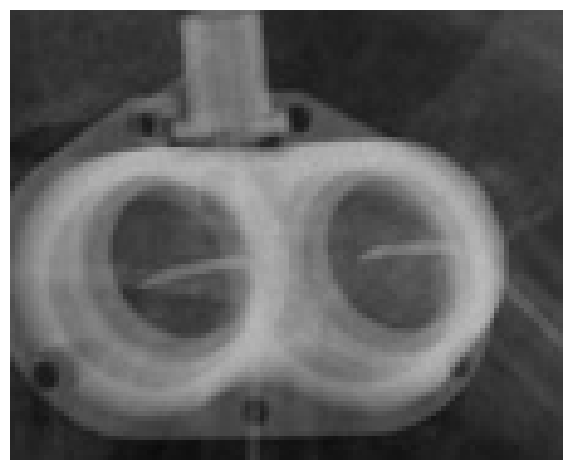



USER:   

Think first, call **image_zoom_in_tool** if needed, then answer. Format strictly as:  <think>...</think>  <tool_call>...</tool_call> (if tools needed)  <answer>...</answer> 

ASSISTANT:   
<think>The zoom-in tool has confirmed that the device in the chest is indeed a pacemaker. Pacemakers are medical devices used to treat heart rhythm disorders. The X-ray does n
ot show any obvious signs of disease such as pneumonia, heart failure, or lung infections. The pacemaker itself is a normal finding in patients with cardiac issues. Therefore,
 the diseases included in the picture are related to cardiac issues, but the pacemaker itself is not a disease.</think>  
<answer>The diseases included in the picture are related to cardiac issues, such as arrhythmia, which is typically managed with the use of a pacemaker. The pacemaker itself is
 a medical device and not a disease.</answer>  
<tool_call>
{"name": "image_zoom_in_tool", "arguments": {"bbox_2d": [665, 286, 778, 378], "label": "p

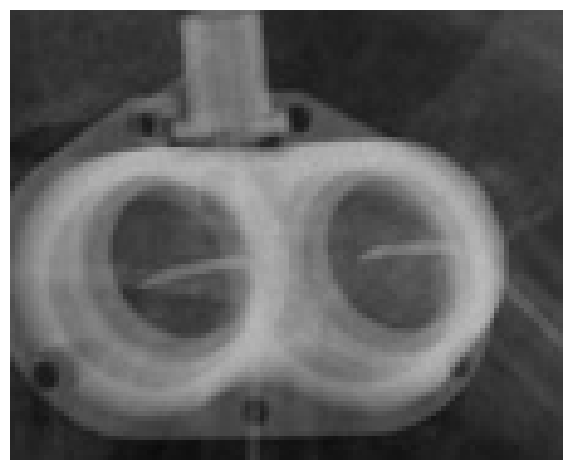



USER:   

Think first, call **image_zoom_in_tool** if needed, then answer. Format strictly as:  <think>...</think>  <tool_call>...</tool_call> (if tools needed)  <answer>...</answer> 



In [71]:
show_thinking(pil_img, print_messages, [])